In [ ]:
import torch
import torch.nn as nn


def init_alexnet_weights(model):
    # 按 AlexNet 风格初始化
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            # conv 权重 ~ N(0, 0.01)
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)
        elif isinstance(m, nn.Linear):
            # fc 权重 ~ N(0, 0.01)，bias = 0
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)


# 定义学生模型 128*128输入，输出类别数为101
class StudentNet(nn.Module):
    def __init__(self, num_classes=101):
        super(StudentNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(384 * 7 * 7, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


class Alexnet(nn.Module):
    def __init__(self, num_classes=101):
        super(Alexnet, self).__init__()
        # 128*128
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 3 * 3, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # 展平
        x = self.classifier(x)
        return x

In [18]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms as T
from PIL import Image
import os
import matplotlib.pyplot as plt


class DataSetLoader(Dataset):
    def __init__(self, root_dir, transform=None,num_classes=101):
        self.root_dir = root_dir
        self.transform = transform
        self.num_classes = num_classes

        # 收集所有 (img_path, label_idx)
        self.samples = []
        self.class_names = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )[:self.num_classes]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # 用 PIL 读图，更稳
        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)
        else:
            # 默认变换
            transform = T.Compose(
                [
                    T.Resize((256, 256)),
                    T.ToTensor(),
                ]
            )
            image = transform(image)

        return image, label

In [19]:
# AlexNet 风格的 RGB intensity 扰动（PCA lighting）
class AlexNetLighting:
    def __init__(self, alphastd=0.1):
        self.alphastd = alphastd
        self.eigval = torch.tensor([0.2175, 0.0188, 0.0045])
        self.eigvec = torch.tensor(
            [
                [-0.5675, 0.7192, 0.4009],
                [-0.5808, -0.0045, -0.8140],
                [-0.5836, -0.6948, 0.4203],
            ]
        )

    def __call__(self, img):
        if self.alphastd == 0:
            return img
        alpha = torch.normal(mean=0.0, std=self.alphastd, size=(3,))
        rgb = (self.eigvec * alpha * self.eigval).sum(dim=1)
        return torch.clamp(img + rgb.view(3, 1, 1), 0.0, 1.0)


# 5-crop（四角+中心）+ 水平翻转 => 每张图 10 个视图
ten_crop_to_tensor = T.Compose(
    [
        T.TenCrop(128),
        T.Lambda(lambda crops: torch.stack([T.ToTensor()(crop) for crop in crops])),
        T.Lambda(lambda crops: torch.stack([AlexNetLighting(alphastd=0.1)(crop) for crop in crops])),
        T.Lambda(
            lambda crops: torch.stack(
                [
                    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(crop)
                    for crop in crops
                ]
            )
        ),
    ]
)

In [ ]:
def loss_compre(input, output_teacher, output_student, temperature=4.0, alpha=0.1):
    # 交叉熵损失（学生输出 logits）
    ce_loss = nn.CrossEntropyLoss()(output_student, input)

    # KL 散度损失：使用 batchmean 与 KL 数学定义一致，避免 future warning
    kl_loss = nn.KLDivLoss(reduction="batchmean")(
        nn.LogSoftmax(dim=1)(output_student / temperature),
        nn.Softmax(dim=1)(output_teacher / temperature),
    ) * (temperature**2)

    # 总损失
    return alpha * ce_loss + (1 - alpha) * kl_loss

In [21]:
from tqdm import tqdm

def train(model_student,model_teacher, epoch, train_loader, optimizer, criterion, device, scheduler):
    correct_ = []
    loss_ = []
    for ep in range(epoch):
        model_student.train()
        model_teacher.eval() 
        total_loss = 0.0
        correct = 0
        total = 0
        for images, labels in tqdm(train_loader, desc=f"训练中 [{ep+1}/{epoch}]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            if images.dim() == 5:
                # 输入为 [B, 10, C, H, W]，将 10 个视图的预测取平均
                bsz, ncrops, c, h, w = images.size()
                outputs_student = model_student(images.view(-1, c, h, w))
                outputs_student = outputs_student.view(bsz, ncrops, -1).mean(dim=1)
                outputs_teacher = model_teacher(images.view(-1, c, h, w))
                outputs_teacher = outputs_teacher.view(bsz, ncrops, -1).mean(dim=1)
            else:
                outputs_student = model_student(images)
                outputs_teacher = model_teacher(images)
            loss = loss_compre(labels, outputs_teacher, outputs_student, temperature=4.0, alpha=0.1)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs_student.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        accuracy = correct / total
        correct_.append(accuracy)
        loss_.append(avg_loss)
        print(
            f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 准确率: {accuracy:.4f} total: {total} correct: {correct}"
        )

        try:
            scheduler.step(accuracy)
        except NameError:
            # 如果 notebook 中没有定义 scheduler，就跳过调度
            pass
    return correct_, loss_

In [22]:
def test(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="测试中"):
            images, labels = images.to(device), labels.to(device)
            if images.dim() == 5:
                bsz, ncrops, c, h, w = images.size()
                outputs = model(images.view(-1, c, h, w))
                outputs = outputs.view(bsz, ncrops, -1).mean(dim=1)
            else:
                outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"测试准确率: {accuracy:.4f}")

In [23]:
def show_correct_and_loss(correct, loss, correct_add=None, loss_add=None):
  if correct_add is not None:
    correct = correct + correct_add
  if loss_add is not None:
    loss = loss + loss_add

  epochs = range(1, len(correct) + 1)

  best_idx_cor = max(range(len(correct)), key=lambda i: correct[i])
  best_idx_loss = min(range(len(loss)), key=lambda i: loss[i])

  fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

  # Accuracy
  axes[0].plot(epochs, correct, marker="o", linewidth=2, label="Accuracy", color="#1f77b4")
  axes[0].scatter(best_idx_cor + 1, correct[best_idx_cor], color="red", s=80, zorder=3, label="Best Accuracy")
  axes[0].annotate(
    f"{correct[best_idx_cor]:.4f}",
    xy=(best_idx_cor + 1, correct[best_idx_cor]),
    xytext=(5, 8),
    textcoords="offset points",
    color="red",
  )
  axes[0].set_title("Training Accuracy")
  axes[0].set_xlabel("Epoch")
  axes[0].set_ylabel("Accuracy")
  axes[0].set_xticks(list(epochs))
  axes[0].grid(True, linestyle="--", alpha=0.4)
  axes[0].legend()

  # Loss
  axes[1].plot(epochs, loss, marker="o", linewidth=2, label="Loss", color="#ff7f0e")
  axes[1].scatter(best_idx_loss + 1, loss[best_idx_loss], color="green", s=80, zorder=3, label="Best Loss")
  axes[1].annotate(
    f"{loss[best_idx_loss]:.4f}",
    xy=(best_idx_loss + 1, loss[best_idx_loss]),
    xytext=(5, 8),
    textcoords="offset points",
    color="green",
  )
  axes[1].set_title("Training Loss")
  axes[1].set_xlabel("Epoch")
  axes[1].set_ylabel("Loss")
  axes[1].set_xticks(list(epochs))
  axes[1].grid(True, linestyle="--", alpha=0.4)
  axes[1].legend()

  plt.tight_layout()
  plt.show()

In [24]:
train_dir = "/data/data_taohy/awesomeCopression/food101_images/train"
test_dir = "/data/data_taohy/awesomeCopression/food101_images/validation"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_teacher = Alexnet(num_classes=5)


teacher_ckpt_path = "/data/data_taohy/modelReShow/AlexNet/alexnet_food5_dataimprovement.pth"
ckpt = torch.load(teacher_ckpt_path, map_location=device)
state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt

# 如果是 DataParallel 保存出来的参数名，去掉 "module." 前缀
if any(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

model_teacher.load_state_dict(state_dict)
model_teacher = model_teacher.to(device)
print("教师模型初始化完成，准备训练...")



model_student = StudentNet(num_classes=5)
init_alexnet_weights(model_student)  # 初始化权重
if torch.cuda.device_count() > 1:
    print("使用多卡训练, GPU 数量:", torch.cuda.device_count())
    model_student = nn.DataParallel(model_student)
model_student = model_student.to(device)


optimizer = torch.optim.SGD(
    model_student.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4
)
scheduler_base = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",  # 监控准确率（越大越好）
    factor=0.1,  # 乘以 0.1（即除以 10）
    patience=5,  # 等待 5 个 epoch 不改善才调整
)

criterion = nn.CrossEntropyLoss()


train_transform = T.Compose(
    [
        T.Resize(150),
        ten_crop_to_tensor,
    ]
)

test_transform = T.Compose(
    [
        T.Resize(150),
        T.TenCrop(128),
        T.Lambda(lambda crops: torch.stack([T.ToTensor()(crop) for crop in crops])),
        T.Lambda(
            lambda crops: torch.stack(
                [
                    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(
                        crop
                    )
                    for crop in crops
                ]
            )
        ),
    ]
)

train_loader = DataLoader(
    DataSetLoader(train_dir, transform=train_transform, num_classes=5),
    batch_size=64,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
)
test_loader = DataLoader(
    DataSetLoader(test_dir, transform=test_transform, num_classes=5),
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
)


if __name__ == "__main__":
    correct, loss = train(
        model_student,
        model_teacher,
        epoch=20,
        train_loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        scheduler=scheduler_base,
    )
    test(model_student, test_loader=test_loader, device=device)

教师模型初始化完成，准备训练...
使用多卡训练, GPU 数量: 4


训练中 [1/20]:   0%|          | 0/59 [00:00<?, ?it/s]/data/xyjiang/anaconda3/envs/thy_env1/lib/python3.11/site-packages/torch/nn/functional.py:3384: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(
训练中 [1/20]: 100%|██████████| 59/59 [00:15<00:00,  3.79it/s]


Epoch [1/20] 平均损失: 3.6131 准确率: 0.2480 total: 3750 correct: 930


训练中 [2/20]: 100%|██████████| 59/59 [00:15<00:00,  3.88it/s]


Epoch [2/20] 平均损失: 3.3001 准确率: 0.3608 total: 3750 correct: 1353


...

Epoch [19/20] 平均损失: 1.1433 准确率: 0.7568 total: 3750 correct: 2838


训练中 [20/20]: 100%|██████████| 59/59 [00:15<00:00,  3.74it/s]


Epoch [20/20] 平均损失: 1.1291 准确率: 0.7613 total: 3750 correct: 2855


测试中: 100%|██████████| 20/20 [00:03<00:00,  6.03it/s]

测试准确率: 0.6656


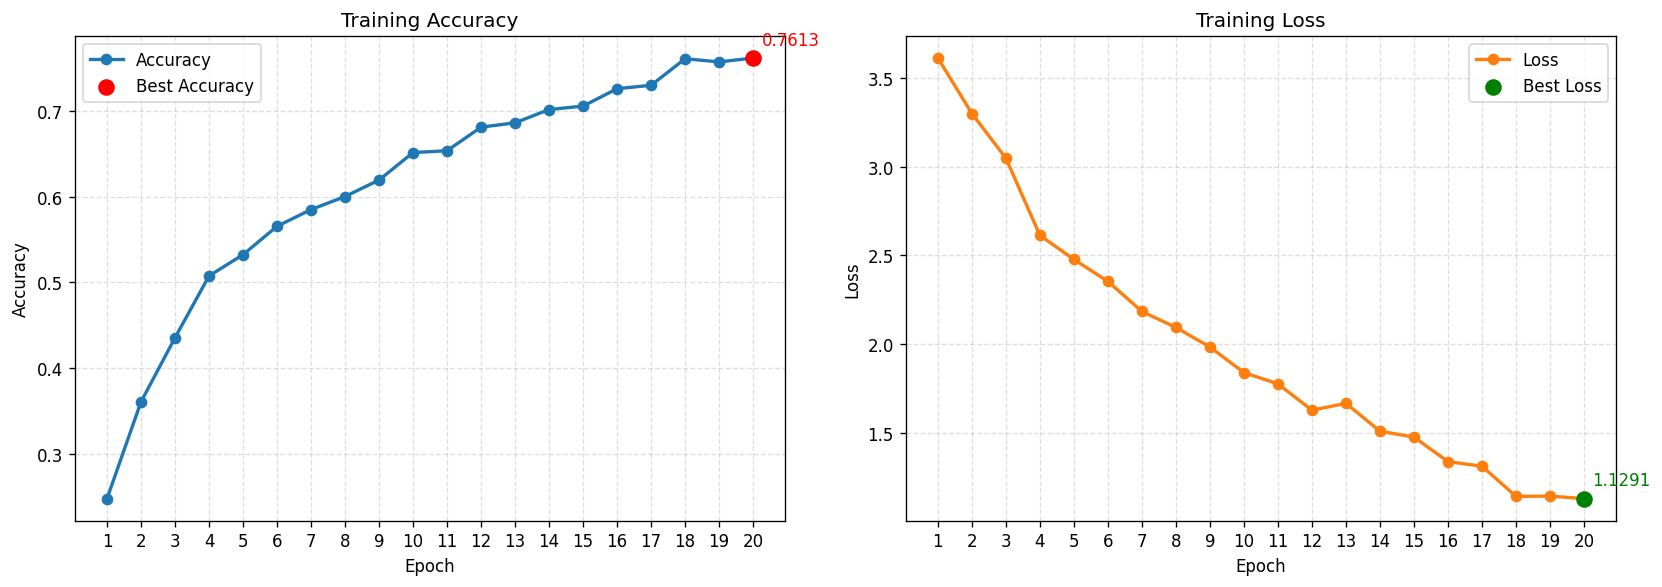

In [25]:
show_correct_and_loss(correct, loss)

In [28]:
correct_add,loss_add = train(
    model_student,
    model_teacher,
    epoch=40,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_base,
)
test(model_student, test_loader=test_loader, device=device)

训练中 [1/40]:   0%|          | 0/59 [00:00<?, ?it/s]/data/xyjiang/anaconda3/envs/thy_env1/lib/python3.11/site-packages/torch/nn/functional.py:3384: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(
训练中 [1/40]: 100%|██████████| 59/59 [00:15<00:00,  3.84it/s]


Epoch [1/40] 平均损失: 0.9732 准确率: 0.7941 total: 3750 correct: 2978


训练中 [2/40]: 100%|██████████| 59/59 [00:15<00:00,  3.84it/s]


Epoch [2/40] 平均损失: 0.8282 准确率: 0.8253 total: 3750 correct: 3095


训练中 [3/40]: 100%|██████████| 59/59 [00:15<00:00,  3.76it/s]


...

Epoch [39/40] 平均损失: 0.0350 准确率: 0.9995 total: 3750 correct: 3748


训练中 [40/40]: 100%|██████████| 59/59 [00:16<00:00,  3.57it/s]


Epoch [40/40] 平均损失: 0.0316 准确率: 0.9997 total: 3750 correct: 3749


测试中: 100%|██████████| 20/20 [00:02<00:00,  7.53it/s]

测试准确率: 0.7120


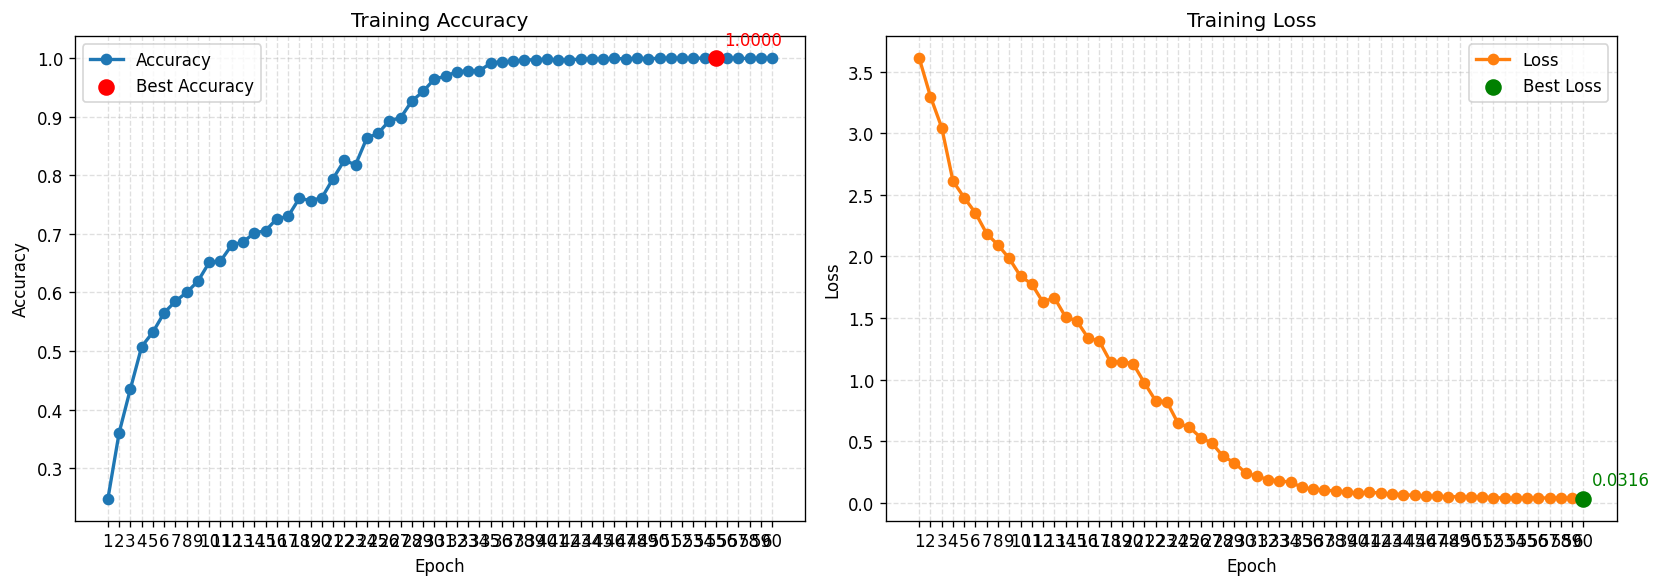

In [29]:
show_correct_and_loss(correct, loss, correct_add, loss_add)

In [26]:
import os
from datetime import datetime

# 保存/加载检查点的实用函数（在新的 notebook cell 中执行）

def save_checkpoint(path, model, optimizer, scheduler=None, epoch=None, best_acc=None):
  os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
  # 如果使用了 DataParallel，保存 module 的 state_dict
  state_dict = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
  checkpoint = {
    "epoch": epoch,
    "model_state_dict": state_dict,
    "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
    "best_acc": best_acc,
    "saved_at": datetime.utcnow().isoformat(),
  }
  torch.save(checkpoint, path)
  print(f"Saved checkpoint to {path}")

def load_checkpoint(path, model, optimizer=None, scheduler=None, map_location=device):
  checkpoint = torch.load(path, map_location=map_location)
  # 如果当前 model 是 DataParallel，需要把 state_dict 加载到 module
  target = model.module if hasattr(model, "module") else model
  target.load_state_dict(checkpoint["model_state_dict"])
  if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
  if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
  print(f"Loaded checkpoint from {path}, epoch={checkpoint.get('epoch')}, best_acc={checkpoint.get('best_acc')}")
  return checkpoint

In [27]:
save_checkpoint(
    "/data/data_taohy/modelReShow/AlexNet/alexnet_food101_student_compression_checkpoint.pth",
    model_student,
    optimizer,
    scheduler_base,
    epoch=20,
    best_acc=max(correct),
)

Saved checkpoint to /data/data_taohy/modelReShow/AlexNet/alexnet_food101_student_compression_checkpoint.pth
